# Enkel datautforskning *Indeks faglig og sosial læringsmiljø*

## Oppsett

In [283]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns

PSY_COL = "indeks_psymiljo_15"
FAGFELT_COL = "fagfelt"
STUDIESTED_COL = "studiested"


# Add project root to path if needed
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

from src.tasks.task_2_1_1.config import DATA_PATH

df = pd.read_excel(DATA_PATH / "programfil_SB2025_portal.xlsx")

## Utforskning

### Manglende verdier

In [284]:
print("---- Missing values ----")
print(f"Total rows {len(df)}")
for variable in [PSY_COL, FAGFELT_COL, STUDIESTED_COL]:
  print(f"Missing values in {variable}: {df[variable].isna().sum()}")

---- Missing values ----
Total rows 1945
Missing values in indeks_psymiljo_15: 757
Missing values in fagfelt: 0
Missing values in studiested: 0


### Unike kategorier

In [285]:
print("---- unique categories ----")
print(f"unique {FAGFELT_COL}: {df[FAGFELT_COL].nunique()}")
print(f"unique {STUDIESTED_COL}: {df[STUDIESTED_COL].nunique()}")

---- unique categories ----
unique fagfelt: 8
unique studiested: 63


### Fordeling av respondenter med hensyn på fagfelt / studiested

In [286]:
response_counts = df.groupby(FAGFELT_COL).size().sort_values(ascending=False)
print("----top 10 field of study by response count ----")
print(response_counts.head(20))

response_counts = df.groupby(STUDIESTED_COL).size().sort_values(ascending=False)
print("\n----top 10 study sites by response count ----")
print(response_counts.head(20))


----top 10 field of study by response count ----
fagfelt
Naturvitenskapelige fag, håndverksfag og tekniske fag    482
Humanistiske og estetiske fag                            349
Helse-, sosial- og idrettsfag                            346
Samfunnsfag og juridiske fag                             255
Lærerutdanninger og utdanninger i pedagogikk             226
Økonomiske og administrative fag                         218
Samferdsels- og sikkerhetsfag og andre servicefag         48
Primærnæringsfag                                          21
dtype: int64

----top 10 study sites by response count ----
studiested
Oslo            464
Bergen          260
Trondheim       229
Tromsø          121
Stavanger       105
Kristiansand     86
Ås               68
Bodø             42
Volda            35
Vestfold         34
Gjøvik           31
Lillehammer      27
Hamar            27
Levanger         24
Ålesund          23
Sogndal          23
Porsgrunn        22
Grimstad         20
Narvik           20
Hald

### Enkel verdispredning

In [287]:
print(f"----score range for {PSY_COL} ----")
print(f"Min: {df[PSY_COL].min()}, Max: {df[PSY_COL].max()}, Mean: {df[PSY_COL].mean():.2f}")


----score range for indeks_psymiljo_15 ----
Min: 2.1458332538604736, Max: 5.0, Mean: 3.83


### Gruppering på fagfelt

In [288]:
avg_by_field = df.groupby(FAGFELT_COL)[PSY_COL].agg(['mean', 'std', 'count']).round(2)
print("---- average score by fagfelt ----")
print(avg_by_field.sort_values('mean', ascending=False))

---- average score by fagfelt ----
                                                    mean   std  count
fagfelt                                                              
Primærnæringsfag                                    4.04  0.36     16
Humanistiske og estetiske fag                       3.97  0.44    144
Naturvitenskapelige fag, håndverksfag og teknis...  3.91  0.38    282
Lærerutdanninger og utdanninger i pedagogikk        3.87  0.42    163
Samferdsels- og sikkerhetsfag og andre servicefag   3.80  0.42     25
Helse-, sosial- og idrettsfag                       3.79  0.44    242
Samfunnsfag og juridiske fag                        3.75  0.37    175
Økonomiske og administrative fag                    3.60  0.38    141


### Gruppering på studiested

In [289]:
top_sites = response_counts.head(5).index
df_top = df[df[STUDIESTED_COL].isin(top_sites)]
avg_by_site = df_top.groupby(STUDIESTED_COL)[PSY_COL].mean().sort_values()
print("---- average score by top 5 study sites ----")
print(avg_by_site)

---- average score by top 5 study sites ----
studiested
Oslo         3.773066
Tromsø       3.811821
Stavanger    3.829469
Bergen       3.836319
Trondheim    3.934106
Name: indeks_psymiljo_15, dtype: float64


### Kjappe figurtester

#### Figurtest 1: Bokslpott, kun de fem største studiestedene

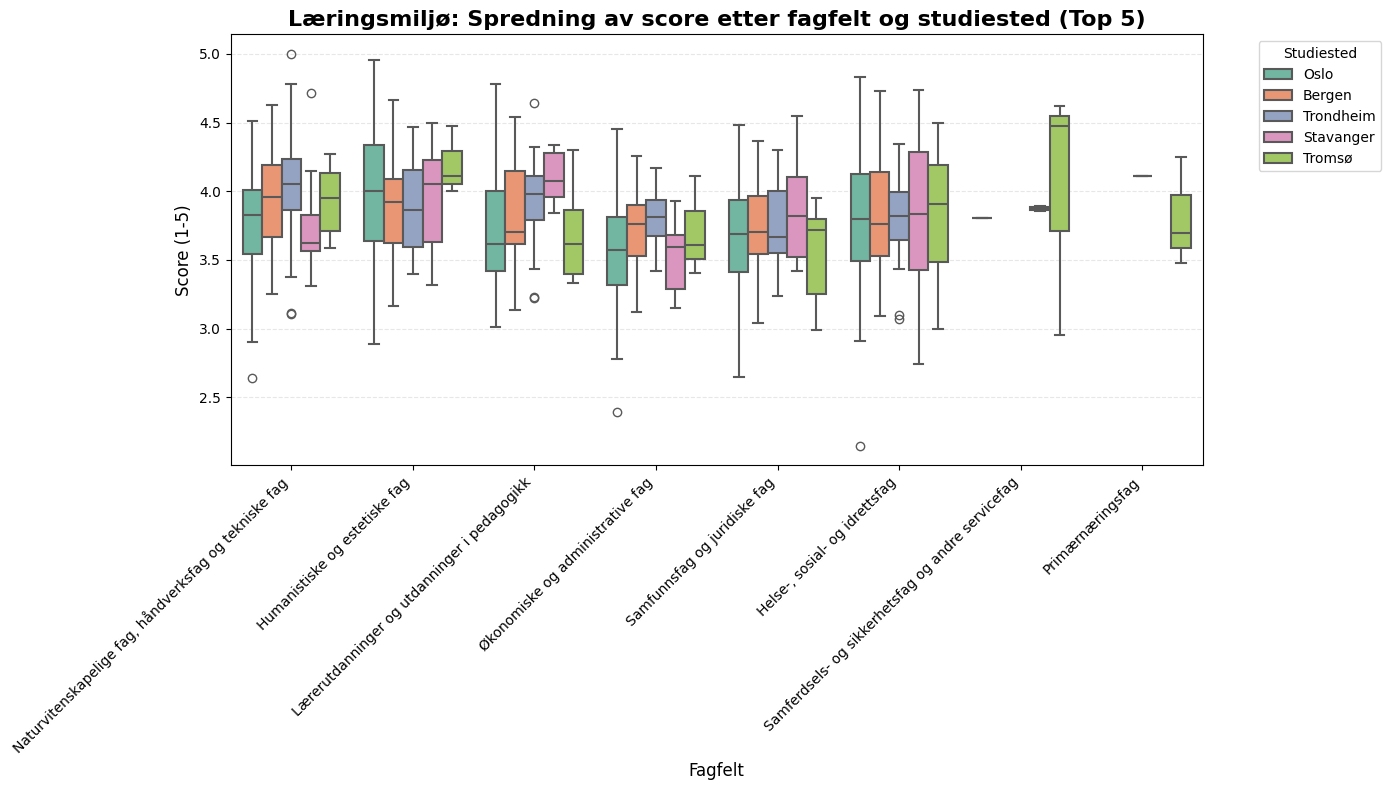

In [290]:
# top 5 sites
top_5_sites = ['Oslo', 'Bergen', 'Trondheim', 'Tromsø', 'Stavanger']
df_filtered = df[df[STUDIESTED_COL].isin(top_5_sites)]

# create box plot
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_filtered, 
    x=FAGFELT_COL, 
    y=PSY_COL, 
    hue=STUDIESTED_COL,
    palette="Set2",
    linewidth=1.5
)

# styles
plt.title("Læringsmiljø: Spredning av score etter fagfelt og studiested (Top 5)", fontsize=16, fontweight='bold')
plt.xlabel("Fagfelt", fontsize=12)
plt.ylabel("Score (1-5)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Studiested', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# display
plt.tight_layout()
plt.show()

### Figurtest 2: Søyler med gjennomsnittsscore per fagfelt

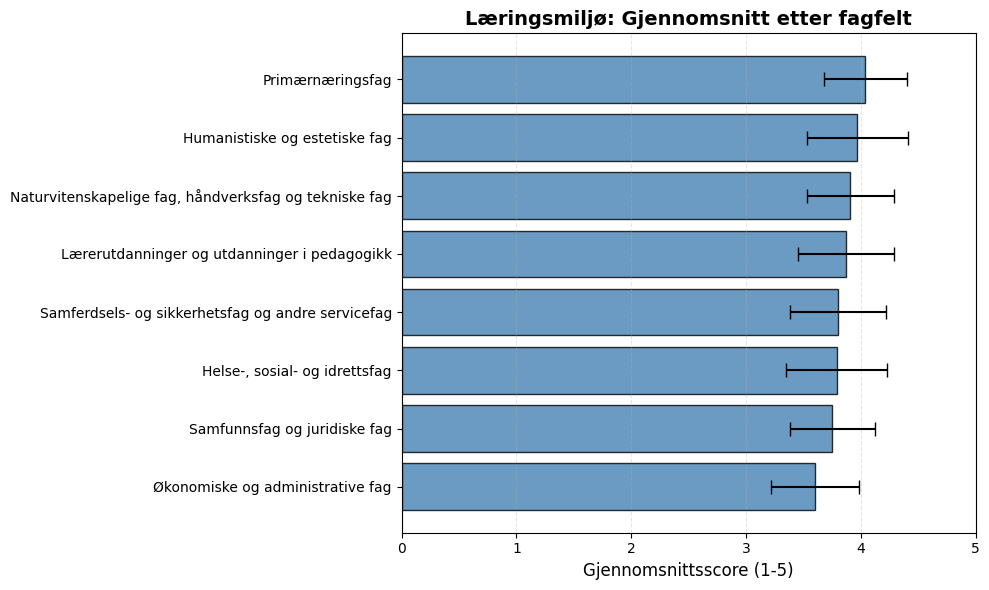

In [291]:
# Setup
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))
DATA_PATH = project_root / "data" / "raw"

# Load and aggregate
df = pd.read_excel(DATA_PATH / "programfil_SB2025_portal.xlsx")
stats = df.groupby(FAGFELT_COL)[PSY_COL].agg(['mean', 'std', 'count']).round(2)
stats = stats.sort_values('mean', ascending=True) 

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
means = stats['mean']
stds = stats['std']

ax.barh(means.index, means, xerr=stds, capsize=5, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Gjennomsnittsscore (1-5)', fontsize=12)
ax.set_title('Læringsmiljø: Gjennomsnitt etter fagfelt', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# display
plt.tight_layout()
plt.show()

### Figurtest 3: Kombinert / sidestilte søylediagrammer med topp 5 studiested og topp 5 fagfelt 

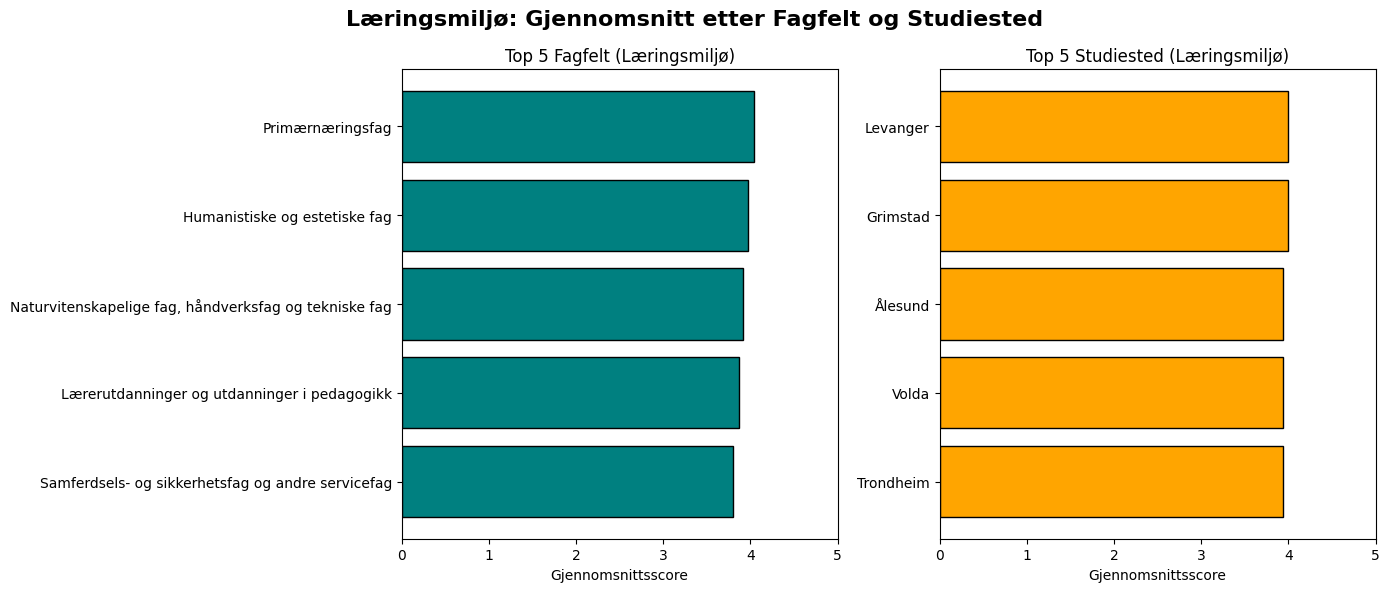

In [292]:
# aggregate by fagfelt (Top 5)
fagfelt_stats = df.groupby(FAGFELT_COL)[PSY_COL].mean().sort_values(ascending=True).tail(5)

# aggregate by studiested (Top 5)
# Ffilter out sites with very low counts first to avoid noise
site_counts = df.groupby(STUDIESTED_COL).size()
valid_sites = site_counts[site_counts >= 20].index # Only sites with 20+ responses
df_valid = df[df[STUDIESTED_COL].isin(valid_sites)]
sted_stats = df_valid.groupby(STUDIESTED_COL)[PSY_COL].mean().sort_values(ascending=True).tail(5)

# create the Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# chart A: fagfelt
ax1.barh(fagfelt_stats.index, fagfelt_stats.values, color='teal', edgecolor='black')
ax1.set_xlabel('Gjennomsnittsscore')
ax1.set_title('Top 5 Fagfelt (Læringsmiljø)')
ax1.set_xlim(0, 5)

# chart B: studiested
ax2.barh(sted_stats.index, sted_stats.values, color='orange', edgecolor='black')
ax2.set_xlabel('Gjennomsnittsscore')
ax2.set_title('Top 5 Studiested (Læringsmiljø)')
ax2.set_xlim(0, 5)

plt.suptitle('Læringsmiljø: Gjennomsnitt etter Fagfelt og Studiested', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Figurtest 4: Gruppert søylediagram topp A studiesteder og for hvert studiested deres topp B fagfelt

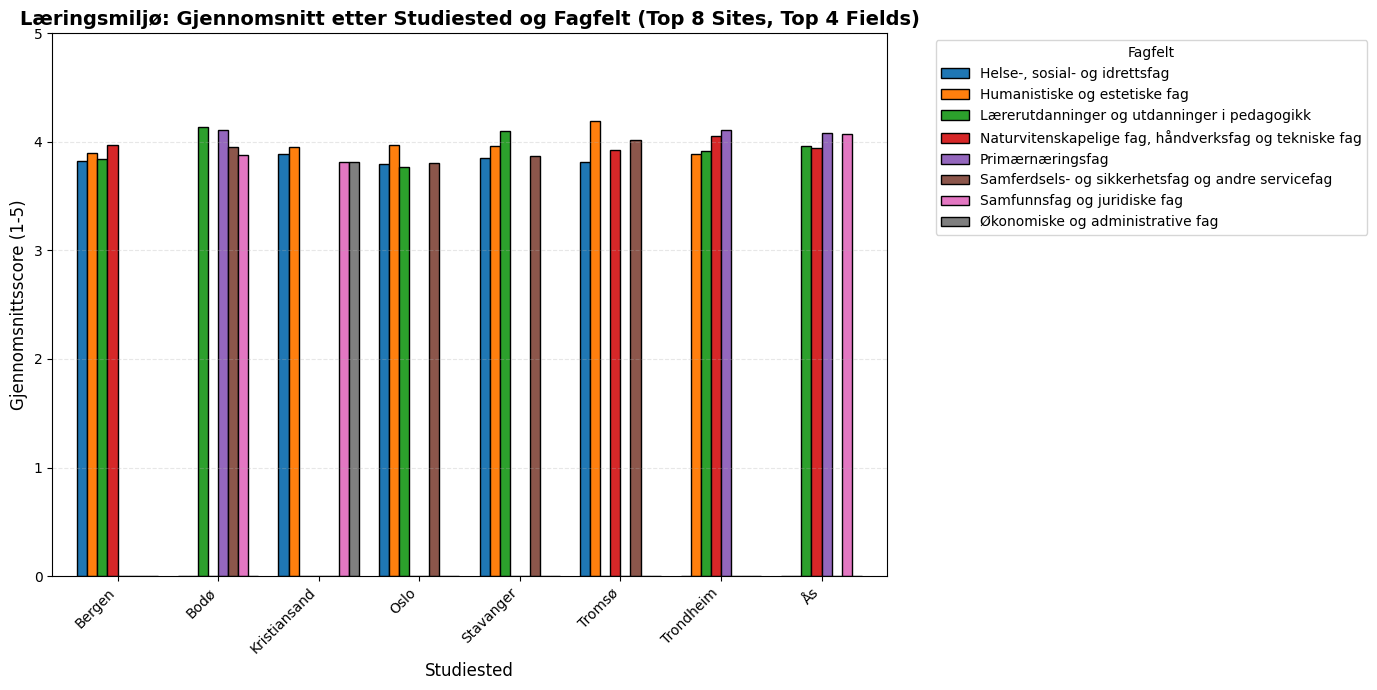

In [293]:


# filter to sites with enough responses (avoid noise)
site_counts = df.groupby(STUDIESTED_COL).size()
valid_sites = site_counts[site_counts >= 20].index
df_valid = df[df[STUDIESTED_COL].isin(valid_sites)]

# get Top 8 Sites by response count
top_sites = df_valid[STUDIESTED_COL].value_counts().head(8).index

# for each site, get Top 4 Fields
results = []
for site in top_sites:
    site_data = df_valid[df_valid[STUDIESTED_COL] == site]
    field_stats = site_data.groupby(FAGFELT_COL)[PSY_COL].mean().sort_values(ascending=False).head(4)
    for field, mean in field_stats.items():
        results.append({'Studiested': site, 'Fagfelt': field, 'Mean': mean})

df_plot = pd.DataFrame(results)

# create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# pivot for plotting
pivot = df_plot.pivot(index='Studiested', columns='Fagfelt', values='Mean')

# plot
pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')

# styling
ax.set_xlabel('Studiested', fontsize=12)
ax.set_ylabel('Gjennomsnittsscore (1-5)', fontsize=12)
ax.set_title('Læringsmiljø: Gjennomsnitt etter Studiested og Fagfelt (Top 8 Sites, Top 4 Fields)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(title='Fagfelt', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# display
plt.tight_layout()
plt.show()

### Figurtest 4.1: Gruppert søylediagram med test av andre/flere visuelle cues

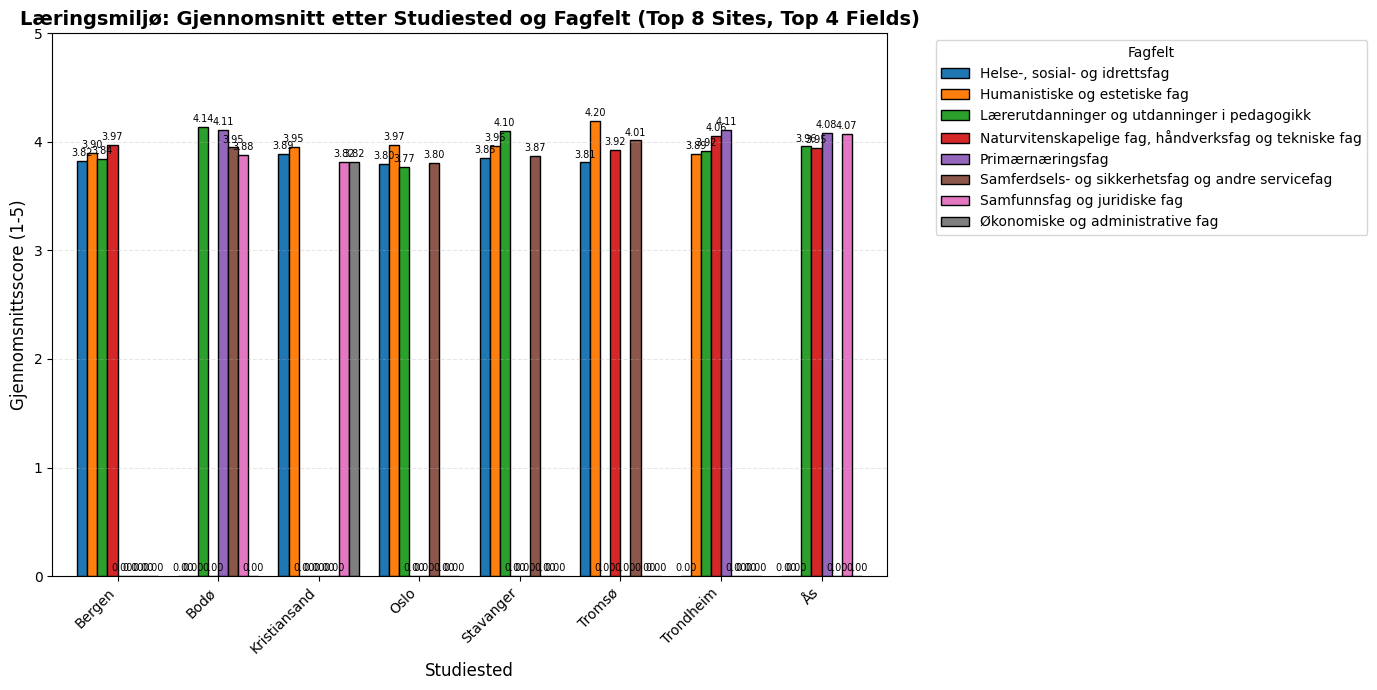

In [294]:
# filter to sites with enough responses (avoid noise)
site_counts = df.groupby(STUDIESTED_COL).size()
valid_sites = site_counts[site_counts >= 20].index
df_valid = df[df[STUDIESTED_COL].isin(valid_sites)]

# get top 8 sites by response count
top_sites = df_valid[STUDIESTED_COL].value_counts().head(8).index

# for each site, get top 4 fields
results = []
for site in top_sites:
    site_data = df_valid[df_valid[STUDIESTED_COL] == site]
    field_stats = site_data.groupby(FAGFELT_COL)[PSY_COL].mean().sort_values(ascending=False).head(4)
    for field, mean in field_stats.items():
        results.append({'Studiested': site, 'Fagfelt': field, 'Mean': mean})

df_plot = pd.DataFrame(results)

# create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# pivot for plotting
pivot = df_plot.pivot(index='Studiested', columns='Fagfelt', values='Mean')

# plot
bars = pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')

# add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2, rotation=0)

# styling
ax.set_xlabel('Studiested', fontsize=12)
ax.set_ylabel('Gjennomsnittsscore (1-5)', fontsize=12)
ax.set_title('Læringsmiljø: Gjennomsnitt etter Studiested og Fagfelt (Top 8 Sites, Top 4 Fields)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(title='Fagfelt', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# display
plt.tight_layout()
plt.show()

### Figurtest 4.2: Diagramforklaring på bunn --> Bredere figur --> mindre overlapp + rotere tall på toppen av søyler

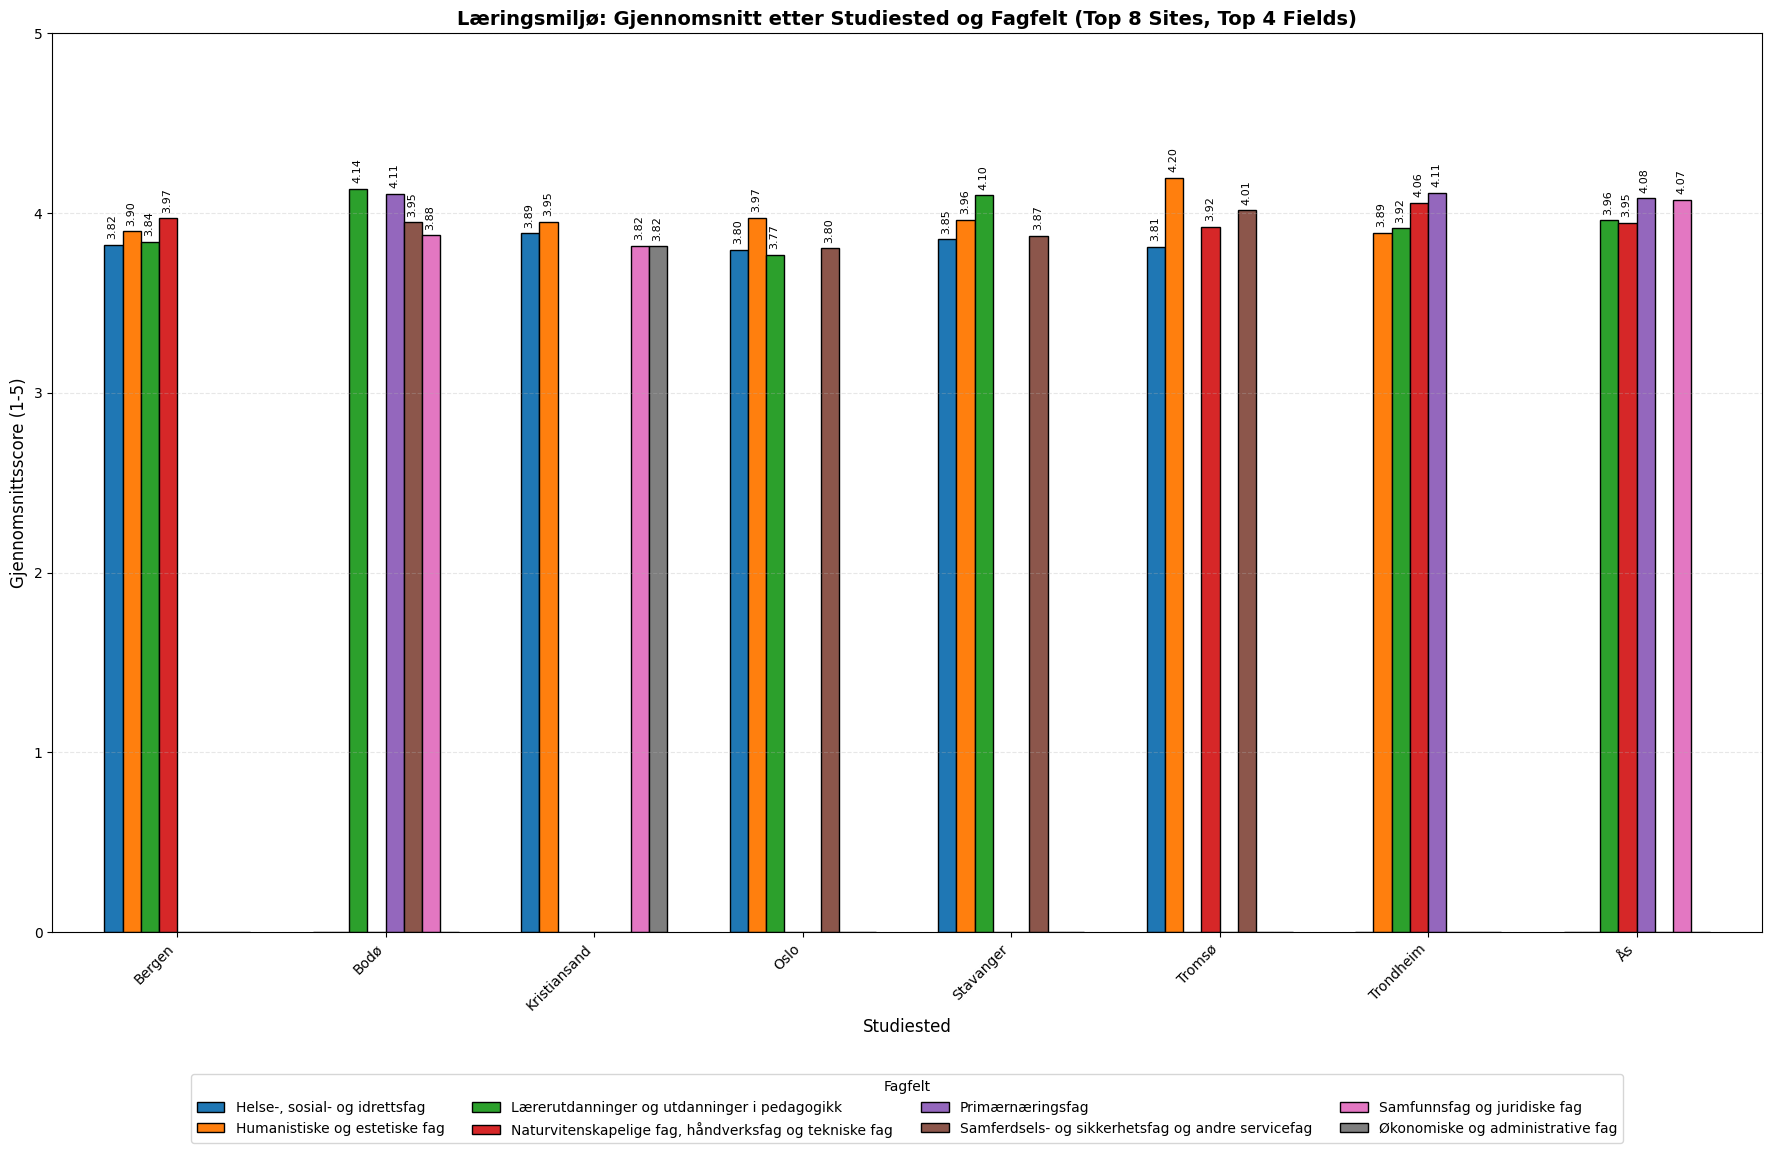

In [295]:

# filter to sites with enough responses (avoid noise)
site_counts = df.groupby(STUDIESTED_COL).size()
valid_sites = site_counts[site_counts >= 20].index
df_valid = df[df[STUDIESTED_COL].isin(valid_sites)]

# get top 8 Sites by response count
top_sites = df_valid[STUDIESTED_COL].value_counts().head(8).index

# for each site, get top 4 fields
results = []
for site in top_sites:
    site_data = df_valid[df_valid[STUDIESTED_COL] == site]
    field_stats = site_data.groupby(FAGFELT_COL)[PSY_COL].mean().sort_values(ascending=False).head(4)
    for field, mean in field_stats.items():
        results.append({'Studiested': site, 'Fagfelt': field, 'Mean': mean})

df_plot = pd.DataFrame(results)

# create the grouped bar chart
fig, ax = plt.subplots(figsize=(18, 14))

# pivot for plotting
pivot = df_plot.pivot(index='Studiested', columns='Fagfelt', values='Mean')

# plot: Reduced width from 0.8 to 0.7 to add space between city groups
bars = pivot.plot(kind='bar', ax=ax, width=0.7, edgecolor='black')

# manually add labels only for bars with actual values
for container in ax.containers:
    for i, rect in enumerate(container):
        height = rect.get_height()
        if height > 0:
            # Calculate position: Center of bar X, slightly ABOVE bar Y
            x_pos = rect.get_x() + rect.get_width() / 2 + 0.02
            y_pos = height + 0.1
            
            ax.text(
                x_pos,
                y_pos,
                f'{height:.2f}',
                ha='center',
                va='bottom',  # Anchor bottom of text to y_pos
                fontsize=8,
                rotation=90,
                rotation_mode='anchor'
            )


# move legend to bottom
ax.legend(title='Fagfelt', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4)

# styling
ax.set_xlabel('Studiested', fontsize=12)
ax.set_ylabel('Gjennomsnittsscore (1-5)', fontsize=12)
ax.set_title('Læringsmiljø: Gjennomsnitt etter Studiested og Fagfelt (Top 8 Sites, Top 4 Fields)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Aajust layout for bottom legend
plt.tight_layout(rect=[0, 0.15, 1, 1])

# display/Save
#plt.savefig('figures/psymiljo_grouped.png', dpi=300, bbox_inches='tight')
plt.show()